# Linear Regression

### Introduction

After learning the fundamentals of supervised learning and the Scikit-learn API in the previous notebook, it's time to apply those concepts to our first regression algorithm. In this notebook, we will explore Linear Regression, understand how it fits the best line to the data, use it to make predictions, and evaluate how well it performs using standard regression metrics.

### Learning Objectives
-  Train a linear regression model and generate predictions.
- Interpret the model's coefficients and intercept.
-  Evaluate a regression model with MAE, RMSE, and R² against a baseline

<hr size="5">

# Section 1 : Key Topics

## what is Linear Regression

> A fundamental supervised learning algorithm used to model the relationship between a dependent variable (lables) and one or more independent variables (features). It predicts continuous values by fitting a straight line that best represents the data.
>
>  **It's a statistical technique used to find the relationship between features and a label.**

## phase 1 : How does it work

### For example 
<span style="font-size: 20px;"> Suppose we want to predict a student's exam score based on the number of hours they studied. As study hours increase, exam scores generally increase as well. Here:</span>

- **Independent variable (input):** Hours studied — this is the factor we control or observe.
- **Dependent variable (output):** Exam score — this is what depends on the hours studied.

**Linear regression uses the independent variable to predict the dependent variable.** [1]

### Imagine we collected the following sample data from a group of students:

| Hours studied (feature) | Exam score (label) |
| ------------------------ | ------------------- |
| 1                         | 52                  |
| 2                         | 58                  |
| 3                         | 64                  |
| 4                         | 71                  |
| 5                         | 76                  |
| 6                         | 82                  |
| 8                         | 90                  |

Text(0.5, 1.0, 'Diagram 1: Hours studied vs. exam score')

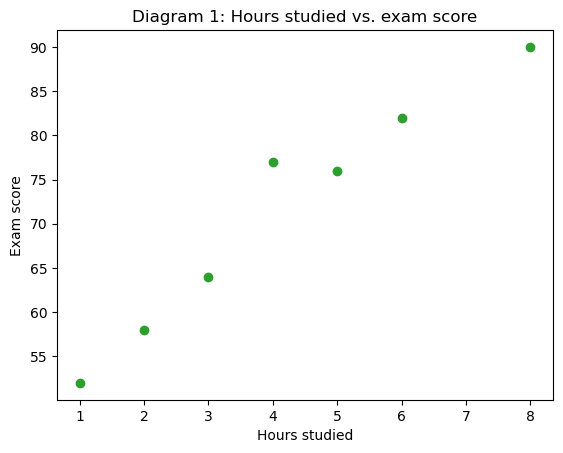

In [2]:
import matplotlib.pyplot as plt


hours_studied = [1, 2, 3, 4, 5, 6, 8]
exam_score = [52, 58, 64, 77, 76, 82, 90]

fig, ax = plt.subplots()
ax.scatter(hours_studied, exam_score, color="tab:green")
ax.set_xlabel("Hours studied")
ax.set_ylabel("Exam score")
ax.set_title("Diagram 1: Hours studied vs. exam score")


> ### Diagram 1 : Plotting the raw data
>A chart of hours studied (x-axis) against exam score (y-axis), where the points trend upward and to the right.


### Best Fit Line
In linear regression, the best-fit line is the straight line that best represents the relationship between the independent variable (input) and the dependent variable (output). The goal is to minimize the difference between the actual data points and the predicted values generated by the model.

> The goal of linear regression is to find a straight line that minimizes the error (the difference) between the observed data points and the predicted values. This line helps us predict the dependent variable for new, unseen data.

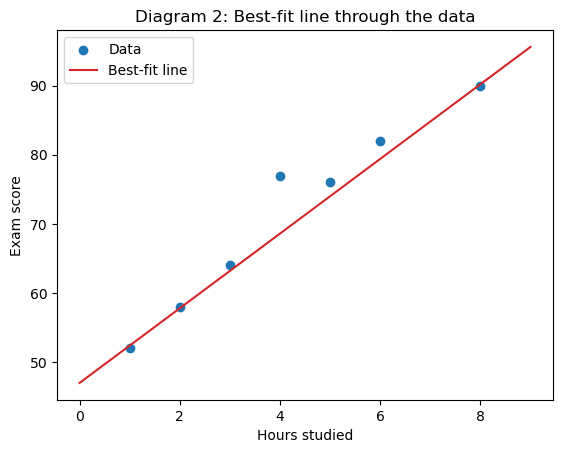

In [20]:
hours_studied = [1, 2, 3, 4, 5, 6, 8]
exam_score =  [52, 58, 64, 77, 76, 82, 90]

bias = 47       # y-intercept
weight = 5.4    # slope

fig, ax = plt.subplots()
ax.scatter(hours_studied, exam_score, color="tab:blue", label="Data")

x_line = [0, 9]
y_line = [bias + weight * x for x in x_line]
ax.plot(x_line, y_line, color="tab:red", label="Best-fit line")

ax.set_xlabel("Hours studied")
ax.set_ylabel("Exam score")
ax.set_title("Diagram 2: Best-fit line through the data")
ax.legend()

> ### Diagram 2 — Adding a best-fit line
> A best-fit line drawn through the study-hours data from Figure 1.

## Linear regression equation

In algebraic terms, this model is defined as:
<span style="font-size: 20px;">$$y = mx + b$$</span>

<span style="font-size: 17px;">where:</span>

- $y$ is the exam score — the value we want to predict.
- $m$ is the slope of the line.
- $x$ is hours studied — our input value.
- $b$ is the y-intercept.

In ML notation, we instead write the equation for a linear regression model as:

<span style="font-size: 20px;">$$ y' = b + w_1x_1 $$</span>

<span style="font-size: 17px;">where:</span>

- $y'$ is the **predicted label** : the output (predicted exam score).
- $b$ is the **bias** of the model. This is the same idea as the y-intercept in the algebraic line equation, and it's sometimes called $w_0$. Bias is a **parameter** that's learned during training.
- $w_1$ is the **weight** on the feature. This plays the same role as the slope $m$ in the algebraic equation. Weight is also a **parameter** learned during training.
- $x_1$ is a **feature** — the input (hours studied).



<span style="font-size: 20px;">During training, the model adjusts the weight and bias so that predictions match the observed data as closely as possible.</span> 

>  <div style="text-align: center;"> <img src="Linear_Regression_equation.png" alt="A descriptive summary of the photo" width="400" > </div>

In our example, if we calculate the weight and bias from the best-fit line we drew, we might get a bias of 47 (where the line crosses the y-axis) and a weight of 5.4 (the slope of the line). The model would then be:

$$ y' = 47 + 5.4x_1 $$

Using this model, a student who studies for 6 hours would have a predicted exam score of $47 + 5.4 \times 6 = 79.4$.


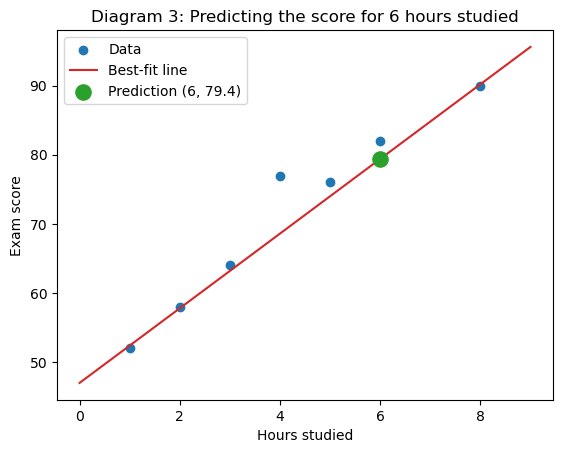

In [14]:
hours_studied = [1, 2, 3, 4, 5, 6, 8]
exam_score = [52, 58, 64, 77, 76, 82, 90]

bias = 47
weight = 5.4
predicted_hours = 6
predicted_score = bias + weight * predicted_hours

fig, ax = plt.subplots()
ax.scatter(hours_studied, exam_score, color="tab:blue", label="Data")

x_line = [0, 9]
y_line = [bias + weight * x for x in x_line]
ax.plot(x_line, y_line, color="tab:red", label="Best-fit line")

ax.scatter([predicted_hours], [predicted_score], color="tab:green",s=120, zorder=5, label=f"Prediction ({predicted_hours}, {predicted_score:.1f})")

ax.set_xlabel("Hours studied")
ax.set_ylabel("Exam score")
ax.set_title("Diagram 3: Predicting the score for 6 hours studied")
ax.legend()

> ### Diagram 3
>  Using the model, a student who studies for 6 hours has a predicted exam score of 79.4.

## Models with multiple features

The example above uses only one feature  (hours studied). A more realistic model might rely on several features at once, each with its own weight ($w_1$, $w_2$, and so on). A model using five features would be written as:

<span style="font-size: 20px;">$$ y' = b + w_1x_1 + w_2x_2 + w_3x_3 + w_4x_4 + w_5x_5 $$</span>




For predicting an exam score, additional useful features might include:

- Class attendance rate
- Hours of sleep the night before the exam
- Number of practice quizzes completed
- Hours spent on social media per day

If we plot a couple of these additional features against the label individually, we can see that they also tend to have a roughly linear relationship with exam score

Text(0.5, 1.0, 'Diagram 4: Social media hours vs. exam score')

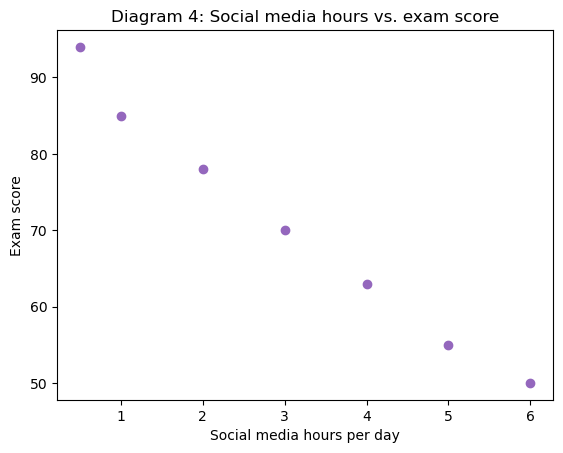

In [9]:
# Diagram 4: daily social media hours vs. exam score (negative trend)."""
social_media_hours = [0.5, 1, 2, 3, 4, 5, 6]
exam_score = [94, 85, 78, 70, 63, 55, 50]

fig, ax = plt.subplots()
ax.scatter(social_media_hours, exam_score, color="tab:purple")
ax.set_xlabel("Social media hours per day")
ax.set_ylabel("Exam score")
ax.set_title("Diagram 4: Social media hours vs. exam score")

> ### Diagram 4 — A feature with a negative relationship
> A student's daily social media use versus their exam score. As social media time increases, exam scores generally decrease.

Text(0.5, 1.0, 'Figure 7: Attendance rate vs. exam score')

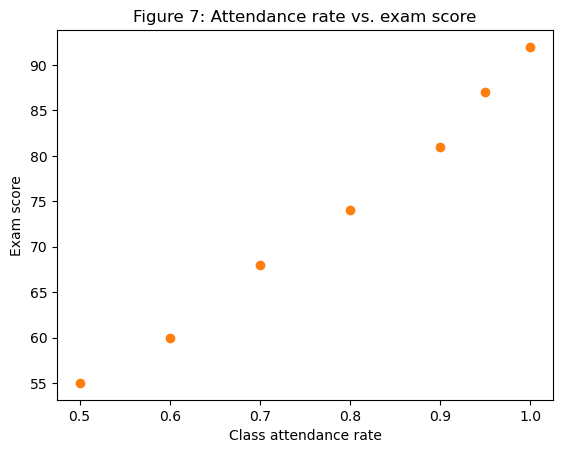

In [13]:
attendance_rate = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
exam_score = [55, 60, 68, 74, 81, 87, 92]

fig, ax = plt.subplots()
ax.scatter(attendance_rate, exam_score, color="tab:orange")
ax.set_xlabel("Class attendance rate")
ax.set_ylabel("Exam score")
ax.set_title("Figure 7: Attendance rate vs. exam score")

> ### Diagram 5 — A feature with a positive relationship
> A student's class attendance rate versus their exam score. As attendance increases, exam scores generally increase as well.


**What parts of the linear regression equation are updated during training?**

- **The bias and weights** —During training, the model updates the bias and weights to better fit the data.


<hr size="5">


## Phase 2 : Interpreting Coefficients


Once a linear regression model is trained, it doesn't just make predictions — it also tells us **how** it makes them. Going back to our example:

<span style="font-size: 20px;">$$y = mx + b$$</span>

- $m$ (the **weight**, also called a **coefficient**) tells us how much the predicted exam score changes for every one-unit increase in hours studied.
- $b$ (the **bias**, also called the **intercept**) is the predicted value when the feature is zero.

For a model with several features, there is **one coefficient per feature** and a **single shared intercept**:

<span style="font-size: 20px;">$$ y' = b + w_1x_1 + w_2x_2 + \dots + w_nx_n $$</span>

> **A coefficient tells you how much the prediction changes when that feature increases by one unit, holding all other features constant.**


### What does `model.coef_` and `model.intercept_` return?

After calling `model.fit(...)`, a trained scikit-learn `LinearRegression` object exposes two attributes:

- **`model.coef_`** — an array with **one weight per feature**, in the same order as the columns of `X_train`.
- **`model.intercept_`** — a single number, the bias term shared by every prediction.


In [ ]:
print(model.coef_)      # e.g. array([5.4])       -> one weight per feature
print(model.intercept_) # e.g. 47.0                -> the bias term


### What does a positive or a negative coefficient mean?

- **Positive coefficient →** as the feature increases, the prediction tends to **increase**. This is a direct relationship.
  - *Example:* Diagram 5 above (class attendance rate vs. exam score) — more attendance, higher predicted score.
- **Negative coefficient →** as the feature increases, the prediction tends to **decrease**. This is an inverse relationship.
  - *Example:* Diagram 4 above (social media hours vs. exam score) — more social media time, lower predicted score.
- **Coefficient close to zero →** the feature has **little to no effect** on the prediction, holding the other features constant.

The **magnitude** (size) of a coefficient reflects how strongly that feature moves the prediction — a larger absolute value means a bigger swing in the predicted output for each one-unit increase in that feature. (This comparison is most meaningful when features are on similar scales, since a coefficient's size also depends on the units of its feature.)


## Phase 3 : Linear regression - Loss


<span style="font-size: 18px;">After training a regression model, we evaluate how well it predicts the target values on the **test set**. Unlike classification, regression models are **not evaluated using accuracy**. Instead, we commonly use **MAE**, **RMSE**, and **R² Score**.   </span> [2]

###  1. Mean Absolute Error (MAE)

#### Definition
The **Mean Absolute Error (MAE)** measures the average absolute difference between the predicted values and the actual values.

### Formula

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

Where:
- $y_i$ = Actual value
- $\hat{y}_i$ = Predicted value
- $n$ = Number of samples

### Interpretation
- Measures the **average prediction error**.
- The error is expressed in the **same unit as the target variable**.
- Lower values indicate a better model.
- Every error contributes equally to the final score.

### Example

If:

| Actual | Predicted |
|--------:|----------:|
| 100 | 95 |
| 150 | 160 |
| 200 | 190 |

Absolute errors:

- $|100-95|=5$
- $|150-160|=10$
- $|200-190|=10$

$$
MAE=\frac{5+10+10}{3}=8.33
$$

**Interpretation:** On average, the model's predictions are **8.33 units away** from the true values.

---

### 2. Root Mean Squared Error (RMSE)

### Definition
The **Root Mean Squared Error (RMSE)** measures the average prediction error while giving **larger errors a much higher penalty**.

### Formula

$$
RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

### Interpretation
- Measures the typical prediction error.
- Uses the same unit as the target variable.
- Large prediction errors have a much greater effect because the errors are squared.
- Lower values indicate better performance.

### Example

Errors:

- 5
- 10
- 10

Squared errors:

- 25
- 100
- 100

$$
RMSE=\sqrt{\frac{25+100+100}{3}}
=\sqrt{75}
\approx8.66
$$

Notice that RMSE is slightly larger than MAE because larger errors receive more weight.

---

### MAE vs RMSE

| MAE | RMSE |
|------|-------|
| Uses absolute errors | Uses squared errors |
| Less affected by large errors | Strongly penalizes large errors |
| Easier to interpret | Better when large mistakes are especially undesirable |

If **RMSE is much larger than MAE**, it usually indicates that the model has **some very large prediction errors (outliers).**

---




### 3. R² Score (Coefficient of Determination)

### Definition

The **R² Score** measures how well the model explains the variation in the target variable.

### Formula

$$
R^2=1-\frac{\sum(y_i-\hat{y}_i)^2}
{\sum(y_i-\bar{y})^2}
$$

Where:

- $\bar{y}$ = Mean of the actual values.

---

### Interpretation

The R² score ranges from negative values up to 1.

| R² Score | Interpretation |
|----------:|---------------|
| 1.00 | Perfect predictions |
| 0.95 | Excellent model |
| 0.80 | Very good model |
| 0.60 | Moderate model |
| 0.30 | Weak model |
| 0.00 | No better than predicting the mean |
| < 0 | Worse than always predicting the mean |

For example:

- **R² = 0.90** means the model explains **90% of the variation** in the target variable.
- **R² = 0.75** means the model explains **75% of the variation**.
- **R² = 0.20** means the model explains only **20% of the variation**.

---

### Which Metrics Are Better?

| Metric | Better Value |
|---------|--------------|
| MAE | Smaller |
| RMSE | Smaller |
| R² Score | Larger (closer to 1) |

---

### Summary

| Metric | What it Measures | Ideal Value |
|---------|------------------|-------------|
| MAE | Average prediction error | As close to 0 as possible |
| RMSE | Prediction error with extra penalty for large errors | As close to 0 as possible |
| R² Score | How well the model explains the data | As close to 1 as possible |

### Rule of Thumb

- **Low MAE** → Predictions are generally close to the true values.
- **Low RMSE** → The model makes few large mistakes.
- **High R²** → The model explains most of the variation in the data.
- **High MAE/RMSE with low R²** → The model performs poorly and may need better features, more data, or a different algorithm.

<hr size="5">


## 1. Training and Predicting


Fitting a linear regression model in scikit-learn always follows the same three steps: import the class, create (instantiate) the model, then call `.fit()` on the training data. Once trained, `.predict()` generates outputs for new, unseen inputs.

- **`LinearRegression()`** — creates an untrained model object.
- **`model.fit(X_train, y_train)`** — trains the model by finding the coefficients and intercept that best fit the training data.
- **`model.predict(X_test)`** — uses the trained model to generate predictions for new feature rows.


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)


## 2. Interpreting Coefficients


After fitting, each feature has a coefficient (its weight) and the model has one intercept (the bias). A coefficient tells you how much the prediction changes when that feature increases by one unit, holding others constant — this interpretability is a major reason linear regression remains widely used even in the deep-learning era.


In [ ]:
print(model.coef_)      # one weight per feature
print(model.intercept_) # the bias term


## 3. Regression Metrics


A regression model's error is measured by how far its predictions land from the true values. The three standard metrics:

| Metric | Meaning | Interpretation |
|--------|---------|-----------------|
| MAE | Mean Absolute Error | Average size of the error, in the target's units — easy to explain |
| RMSE | Root Mean Squared Error | Like MAE but penalizes large errors more heavily |
| R² | Coefficient of determination | Fraction of variance explained; 1.0 is perfect, 0 is no better than the mean |


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print(mean_absolute_error(y_test, predictions))
print(np.sqrt(mean_squared_error(y_test, predictions)))  # RMSE
print(r2_score(y_test, predictions))


> Always compare a model's metric against a simple baseline (e.g. predicting the mean for every row) to judge whether the model is actually adding value.


<hr size="5">


# Section 2 : Hands-on Lab


## Step 1: Train a LinearRegression model on a provided regression dataset (e.g. house prices)

#### 1. Loading the Diabetes dataset using the load_diabetes API function.
this dataset contains 442 samples with 10 baseline physiological and blood serum features.

**read more about the dataset :** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html

In [76]:
import sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


X, y = fetch_california_housing(return_X_y=True)

#### 2.  Split the dataset into training and testing sets

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#### 3. Picking the Linear Regression model and fitting the training set into it to make prediction

In [87]:
# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

#### 4. Illustrating the results

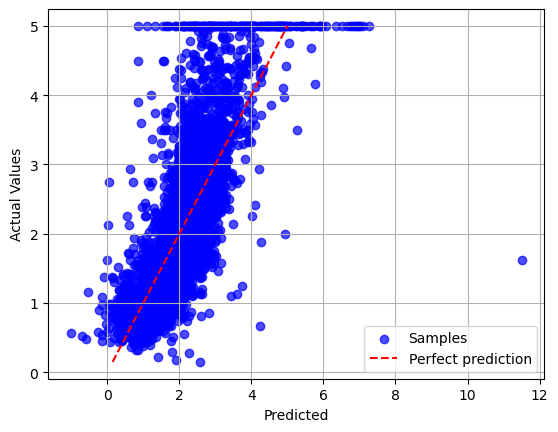

In [79]:
import matplotlib.pyplot as plt
plt.scatter(y_pred, y_test, color='blue', alpha=0.7, label='Samples')

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         'r--',
         label='Perfect prediction')

plt.xlabel("Predicted")
plt.ylabel("Actual Values")
plt.legend()
plt.grid(True)
plt.show()

> #### A lot of points are distributed around the red line, which indicates that the Linear Regression model performs reasonably well. However, the spread of points away from the line shows that the predictions are not perfect, meaning there are factors affecting house prices that are not captured by the available features.

## Step 2: Report the model's coefficients and identify which feature has the strongest effect.

`model.coef_ `returns one coefficient (weight) per feature (column)

In [83]:
print(model.coef_) # one weight per feature


[ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]


In [86]:
print(model.coef_)
print(model.intercept_)

coef_table = pd.DataFrame({
    "Feature": data.feature_names,
    "Coefficient": model.coef_
})

print(coef_table)

[ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
-37.02327770606391
      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708


> ####  AveBedrms has the highest coefficient so the model gives this feature the largest weight. mraning this feature is the most important factor affecting house prices

## Step 3: Evaluate the model with MAE, RMSE, and R² on the test set

In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.533200130495699
RMSE: 0.7455813830127747
R²  : 0.5757877060324528


#### Model Evaluation 


- **MAE = 0.533**
  - The model's predictions are, on average, **0.533 units away** from the actual values.
  - A lower MAE means the predictions are closer to the real values.

- **RMSE = 0.746**
  - RMSE is slightly higher than MAE because it gives more importance to large errors.
  - This means the model has some larger prediction mistakes.

- **R² = 0.576**
  - The model explains about **57.6% of the differences in house values**.
  - The remaining 42.4% may be affected by other factors that are not included in the dataset.

Overall, the model has a **moderate performance**. It learned a relationship between the housing features and prices, but its predictions are not perfect.

## Step 4: Compare the RMSE against a baseline that predicts the mean for every row, and state whether the model adds value.

**Baseline RMSE** measures the error of a simple model that always predicts the average target value without using any features.

**Model RMSE** measures the error of the trained Linear Regression model that uses the dataset features to make predictions.

A lower Model RMSE compared to the Baseline RMSE means the model learned useful patterns and performs better than a simple average prediction.

In [88]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Baseline prediction: always predict the mean value
baseline_pred = np.full_like(y_test, y_train.mean())

# Calculate baseline RMSE
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Model RMSE:", rmse)
print("Baseline RMSE:", baseline_rmse)

Model RMSE: 0.7455813830127747
Baseline RMSE: 1.1448563543099792



- **Model RMSE = 0.746**
- **Baseline RMSE = 1.145**

> #### The Linear Regression model has a lower RMSE than the baseline, which means it makes smaller prediction errors. This shows that the model adds value because it uses the housing features to make better predictions than simply predicting the average house value for all samples.

<hr size="5">

# References:

- [1] Adapted, in an original write-up with an original example (Students performence in exams), from the structure of Google's Machine Learning Crash Course page "Linear regression.": https://developers.google.com/machine-learning/crash-course/linear-regression
  >Diagrams are represented here as Python/matplotlib functions rather than static images.
  >
- [2] Read more about loss in Linear Regression : https://developers.google.com/machine-learning/crash-course/linear-regression/loss